# 单车骑行距离和流量关系分布

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
df=pd.read_csv('df_.csv')  #根据条件过滤后的北京市单车数据
df

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,duration(s),distance(m)
0,1893973,451147,210617,2,2017-05-14 22:16:50,wx4snhx,wx4snhj,116.289597,40.103531,116.286850,40.100784,1,141,587
1,4657992,1061133,465394,1,2017-05-14 22:16:52,wx4dr59,wx4dquz,116.325302,39.790421,116.322556,39.797287,1,265,1104
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,2604
3,3936364,467449,403224,1,2017-05-14 22:16:50,wx4g27p,wx4g266,116.388474,39.963455,116.381607,39.959335,1,250,1042
4,5163705,917620,509044,1,2017-05-14 22:16:53,wx4gd2e,wx4g6pw,116.470871,39.993668,116.464005,39.988174,1,231,962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094280,308143,683030,42881,1,2017-05-23 06:20:55,wx4gjs9,wx4gjs0,116.610947,39.927750,116.609573,39.925003,1,103,429
3094281,1886236,394183,209895,2,2017-05-23 06:20:57,wx4fd57,wx4fd4d,116.459885,39.832993,116.458511,39.828873,1,560,2333
3094282,2162814,878844,235870,2,2017-05-23 06:20:56,wx4fbyv,wx4g08r,116.407700,39.896164,116.399460,39.904404,1,385,1604
3094283,3702730,104540,380669,1,2017-05-23 06:20:56,wx4u11d,wx4u10c,116.414566,40.087051,116.413193,40.082932,1,123,512


In [3]:
ser=df['distance(m)'].value_counts()
ser1=ser.index.tolist()   #骑行距离
ser2=ser.values.tolist()  #骑行流量

In [5]:
ser1_=[]
for i in ser1:
    ser1_.append(i/1000)

In [75]:
def log_pdf(x,y):   #求取pdf
    bins=np.logspace(2, 5,20)
    bins2=list(bins)
    bins_all={}
    for i in range(len(bins)-1):
        bins_all[bins[i]]=[]
    widths = (bins[1:] - bins[:-1])
    for i in range(len(x)):
        for j in range(len(bins)):
            if(x[i]<bins[j]):
                bins_all[bins[j-1]].append(y[i])
                break
            if(x[i]==bins[j]):
                bins_all[bins[j]].append(y[i])
                break
    x_new=[]
    y_new=[]
    for key,value in bins_all.items():
        if(len(value)>0):
            index_this=bins2.index(key)
            y_new.append(np.sum(value)/widths[index_this])
#            y_new.append(np.mean(value))
            x_new.append(key)
        
    return x_new,y_new

In [76]:
a,b=log_pdf(ser1,ser2)

In [77]:
a_=[]
for i in a:
    a_.append(i/1000)

In [78]:
logser1=[]
logser2=[]
for i in range(len(a)):
    logser1.append(math.log10(a_[i]))
    logser2.append(math.log10(b[i]))

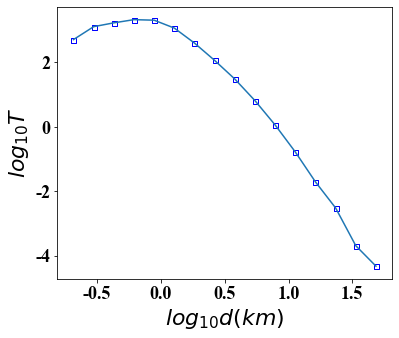

In [79]:
fig= plt.figure(figsize=(6,5))        #一个区域的出和进流量
ax = fig.add_subplot(1,1,1) 
plt.scatter(logser1,logser2,marker = 's',color="w",linewidths=1,s=25,edgecolors='blue')
plt.plot(logser1,logser2) 
#plt.scatter(eR1,eavdT1,alpha=0.2,label='in')
#plt.scatter(popnu,intr,marker = 's',color="w",linewidths=1,s=20,edgecolors='red',label="Tin",alpha=0.6)
#plt.plot( eavd,eloc_num, marker='.',color="red",label="in_Tij",alpha=0.1)
#plt.legend(loc="best",prop={"family" : "Times New Roman",'size':18})
#ax.set_yscale("log")
#ax.set_xscale("log")
#plt.xlim(10^0,10^10)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
ax.set_ylabel(r'$ log_{10}T $',size=22,family='Times New Roman')  
ax.set_xlabel('$log_{10}d(km)$',size=22,family='Times New Roman')
plt.tick_params(labelsize=18)
#plt.savefig('只进只出区域出发点终点距市中心的距离差.pdf')